<a href="https://colab.research.google.com/github/Sahil-1010/Weighted_consensus/blob/main/Weighted_consensus_2.0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Imports**

In [ ]:
#important install
!pip install -U scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 11.6 MB/s eta 0:00:00


## Section 1: Load  **Data**

In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering, OPTICS, DBSCAN
from sklearn.mixture import GaussianMixture

from scipy.cluster.hierarchy import linkage, dendrogram
import skfuzzy as fuzz

# Plot aesthetics
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load dataset
# file = input("Enter file name here (only CSV files): ") #input from user or direct use
# df = pd.read_csv(file, header=0)
df = pd.read_csv("Wine.csv", header=0)

# Show basic info to verify it loaded properly
print("\nFirst few rows of the dataset:")
print(df.head())

print("\nColumn names in the dataset:")
print(df.columns)

# Initialize silhouette cache
silhouette_cache = {}



First few rows of the dataset:
   Alcohol  Malic_Acid   Ash  Ash_Alcanity  Magnesium  Total_Phenols  \
0    14.23        1.71  2.43          15.6        127           2.80   
1    13.20        1.78  2.14          11.2        100           2.65   
2    13.16        2.36  2.67          18.6        101           2.80   
3    14.37        1.95  2.50          16.8        113           3.85   
4    13.24        2.59  2.87          21.0        118           2.80   

   Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  Color_Intensity   Hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   OD280  Proline  Customer_Segment  
0   3.92     1065     

## preprocessing and **best_k**

 Finding optimal k using silhouette scores...
  k=2: score=0.4919
  k=3: score=0.6024
  k=4: score=0.5103
  k=5: score=0.4691
  k=6: score=0.4428
  k=7: score=0.4237
  k=8: score=0.4226
  k=9: score=0.4072
  k=10: score=0.4042


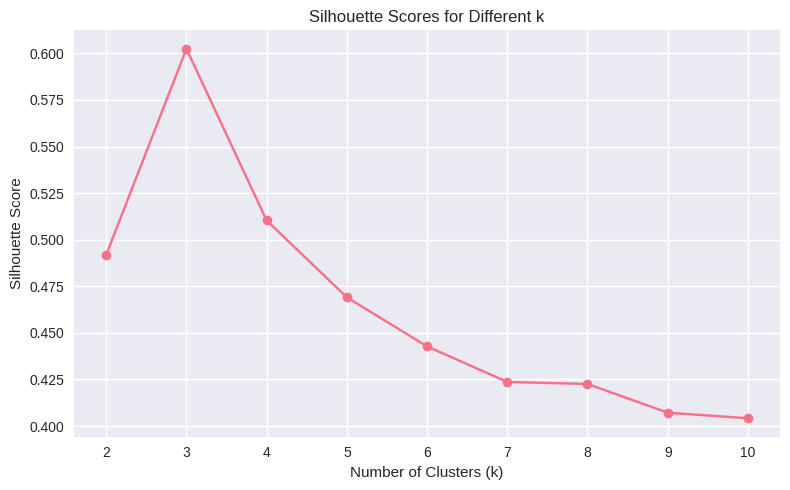

Best k: 3 (score=0.6024)
 Optimal number of clusters: 3


In [ ]:
from sklearn.utils import resample

# Subsample if too big dataset
from sklearn.cluster import MiniBatchKMeans

def fast_structured_subsample(X, sample_size=5000, n_clusters=50, random_state=42):
    if len(X) <= sample_size:
        return X

    print(f" Fast structured subsampling: clustering into {n_clusters} groups...")

    # Cluster the data into regions
    kmeans = MiniBatchKMeans(n_clusters=n_clusters, batch_size=1000, random_state=random_state)
    cluster_labels = kmeans.fit_predict(X)

    # Sample proportionally from each cluster
    subsample_idx = []
    for cluster_id in np.unique(cluster_labels):
        cluster_indices = np.where(cluster_labels == cluster_id)[0]
        n_samples = int(sample_size * len(cluster_indices) / len(X))
        n_samples = min(len(cluster_indices), max(1, n_samples))
        sampled = np.random.choice(cluster_indices, size=n_samples, replace=False)
        subsample_idx.extend(sampled)

    return X[subsample_idx]

# Clean + Encode + Scale
df.drop(columns=['ID', 'Dt_Customer'], inplace=True, errors='ignore')
df.dropna(inplace=True)
df_encoded = pd.get_dummies(df, drop_first=True)
X = StandardScaler().fit_transform(df_encoded)

# Subsample large data
X_sub = fast_structured_subsample(X, sample_size=5000)

# PCA for plotting
X_red = PCA(n_components=2).fit_transform(X_sub)


import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

def find_best_k(X, k_range=range(2, 11)):
    print(" Finding optimal k using silhouette scores...")
    best_k, best_score = 2, -1
    scores = []

    for k in k_range:
        try:
            labels = KMeans(n_clusters=k, n_init='auto', random_state=42).fit_predict(X)
            score = silhouette_score(X, labels)
            scores.append((k, score))
            print(f"  k={k}: score={score:.4f}")
            if score > best_score:
                best_score = score
                best_k = k
        except Exception as e:
            print(f"  ⚠️ Failed for k={k}: {str(e)}")
            scores.append((k, -1))  # Using -1 for failed attempts

    # Plot silhouette scores
    ks, silhouette_scores = zip(*scores)
    plt.figure(figsize=(8, 5))
    plt.plot(ks, silhouette_scores, marker='o', linestyle='-')
    plt.title("Silhouette Scores for Different k")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Silhouette Score")
    plt.xticks(ks)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"Best k: {best_k} (score={best_score:.4f})")
    return best_k


k_best = find_best_k(X_red)
print(f" Optimal number of clusters: {k_best}")


## all alogos and **plots**

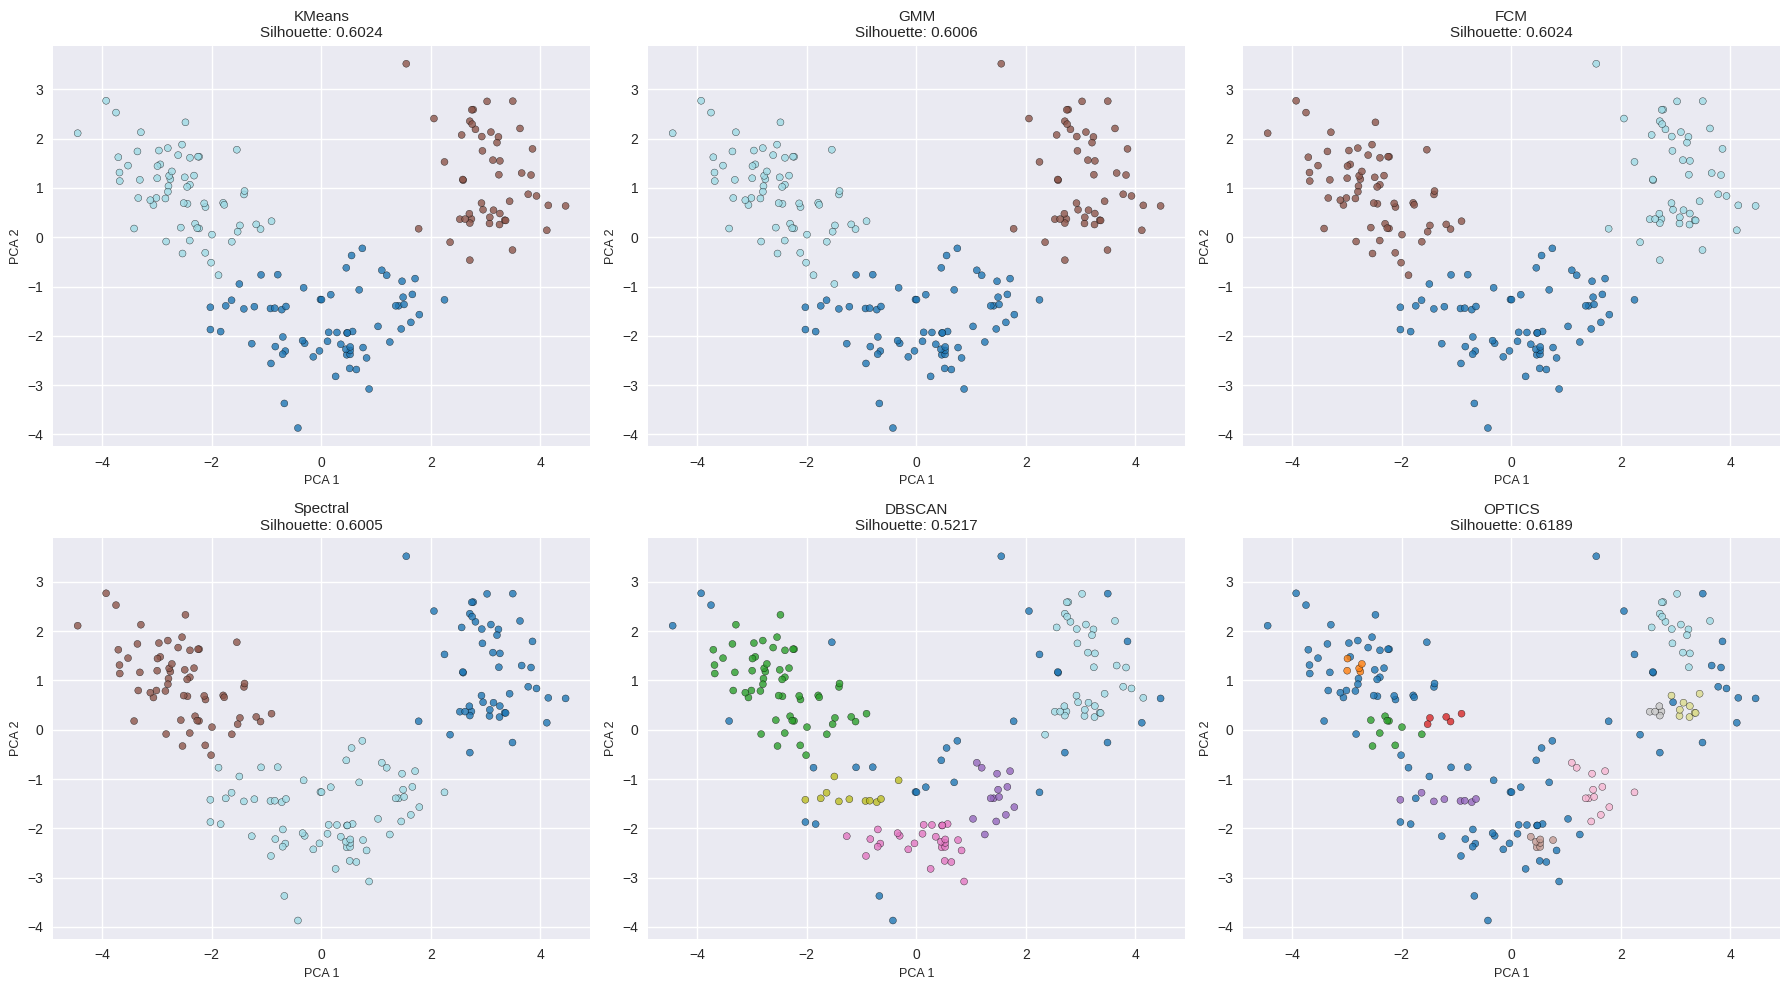

In [ ]:
# Safe silhouette helper
def safe_silhouette(X, labels, sample_size=1000):
    if len(set(labels)) < 2:
        return 0
    try:
        if len(X) > sample_size:
            idx = np.random.choice(len(X), sample_size, replace=False)
            return silhouette_score(X[idx], labels[idx])
        return silhouette_score(X, labels)
    except:
        return 0

# all clustering methods
def run_clustering_ensemble(X, n_clusters):
    cluster_outputs, cluster_scores, cluster_label_list = [], [], []

    # KMeans
    km = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    km_labels = km.fit_predict(X)
    cluster_outputs.append(km_labels)
    score = safe_silhouette(X, km_labels)
    cluster_scores.append(score)
    cluster_label_list.append((km_labels, "KMeans"))

    # GMM
    try:
        gmm = GaussianMixture(n_components=n_clusters, random_state=42)
        gmm_labels = gmm.fit_predict(X)
        score = safe_silhouette(X, gmm_labels)
        cluster_outputs.append(gmm_labels)
        cluster_scores.append(score)
        cluster_label_list.append((gmm_labels, "GMM"))
    except:
        pass

    # FCM
    cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(X.T, c=n_clusters, m=2, error=0.005, maxiter=1000, seed=42)
    fcm_labels = np.argmax(u, axis=0)
    score = safe_silhouette(X, fcm_labels)
    cluster_outputs.append(fcm_labels)
    cluster_scores.append(score)
    cluster_label_list.append((fcm_labels, "FCM"))

    # Agglomerative
    # try:
    #     ag = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage_type)
    #     labels = ag.fit_predict(X)
    #     score = safe_silhouette(X, labels)
    #     cluster_outputs.append(labels)
    #     cluster_scores.append(score)
    #     cluster_label_list.append((labels, f"Agglo-{linkage_type}"))
    # except:
    #     pass

    # Spectral
    try:
        sp = SpectralClustering(n_clusters=n_clusters, affinity='nearest_neighbors', assign_labels='kmeans', random_state=42)
        labels = sp.fit_predict(X)
        score = safe_silhouette(X, labels)
        cluster_outputs.append(labels)
        cluster_scores.append(score)
        cluster_label_list.append((labels, "Spectral"))
    except:
        pass

    # DBSCAN
    db = DBSCAN(eps=0.5, min_samples=5).fit(X)
    db_labels = db.labels_
    score = safe_silhouette(X[db_labels != -1], db_labels[db_labels != -1]) if len(set(db_labels) - {-1}) > 1 else 0
    cluster_outputs.append(db_labels)
    cluster_scores.append(score)
    cluster_label_list.append((db_labels, "DBSCAN"))

    # OPTICS
    op = OPTICS(min_samples=5, xi=0.05).fit(X)
    op_labels = op.labels_
    score = safe_silhouette(X[op_labels != -1], op_labels[op_labels != -1]) if len(set(op_labels) - {-1}) > 1 else 0
    cluster_outputs.append(op_labels)
    cluster_scores.append(score)
    cluster_label_list.append((op_labels, "OPTICS"))

    return cluster_outputs, cluster_scores, cluster_label_list

# Execute all clustering
cluster_outputs, cluster_scores, cluster_label_list = run_clustering_ensemble(X_red, k_best)

# Grid-style plot for all clustering results
def plot_all_algorithms_grid(X, label_score_name_list, sample_size=3000, plots_per_row=3):
    n = len(label_score_name_list)
    rows = (n + plots_per_row - 1) // plots_per_row

    fig, axes = plt.subplots(rows, plots_per_row, figsize=(6 * plots_per_row, 5 * rows))
    axes = axes.flatten()

    for i, ((labels, name), score) in enumerate(label_score_name_list):
        n_points = len(X)
        if n_points > sample_size:
            idx = np.random.choice(n_points, sample_size, replace=False)
            X_plot = X[idx]
            labels_plot = np.array(labels)[idx]
        else:
            X_plot = X
            labels_plot = labels

        ax = axes[i]
        scatter = ax.scatter(X_plot[:, 0], X_plot[:, 1], c=labels_plot, cmap='tab20', s=25, edgecolor='k', alpha=0.8)
        ax.set_title(f"{name}\nSilhouette: {score:.4f}", fontsize=11)
        ax.set_xlabel("PCA 1", fontsize=9)
        ax.set_ylabel("PCA 2", fontsize=9)
        ax.grid(True)

    # Hide any empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

#  Plot all algorithms together
plot_all_algorithms_grid(X_red, list(zip(cluster_label_list, cluster_scores)))


## **Matrix**

Debug Info:
 - Number of clusterings: 6
 - Each clustering length: [178, 178, 178, 178, 178, 178]
 - Cluster scores: [np.float64(0.6024415520362845), np.float64(0.6006019661160786), np.float64(0.6024415520362845), np.float64(0.6004799249463151), np.float64(0.5216517535598502), np.float64(0.6189409601424675)]
 - Method: weighted
 Starting consensus matrix visualization...
Matrix shape: (178, 178)
Sampled matrix shape: (178, 178)
Condensed distance shape: (15753,)
Linkage matrix shape: (177, 4)


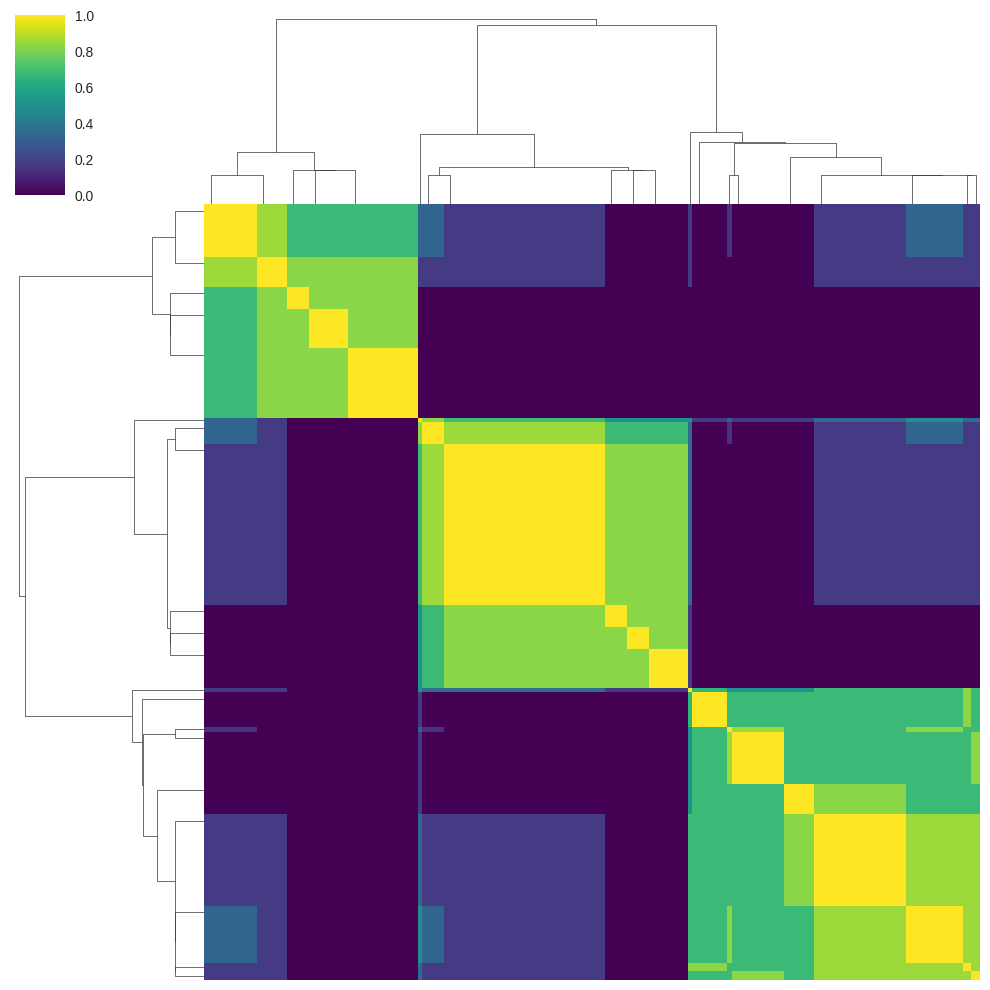

Visualization completed.


In [ ]:
# Build consensus matrix
def create_enhanced_consensus_matrix(cluster_outputs, cluster_scores, method='weighted'):
    n = len(cluster_outputs[0])
    consensus_matrix = np.zeros((n, n))

    if method == 'weighted':
        total_weight = np.sum(cluster_scores)
        for labels, score in zip(cluster_outputs, cluster_scores):
            sim = np.equal.outer(labels, labels).astype(float)
            consensus_matrix += sim * score
        consensus_matrix /= total_weight

    elif method == 'binary':
        for labels in cluster_outputs:
            sim = np.equal.outer(labels, labels).astype(float)
            consensus_matrix += sim
        consensus_matrix /= len(cluster_outputs)
    print_debug_info(cluster_outputs, cluster_scores, method)
    return np.clip(consensus_matrix, 0, 1)

# Consensus matrix visualization (subset)
def visualize_consensus_matrix(matrix, sample_size=1000):
    print(" Starting consensus matrix visualization...")
    try:
        # Step 1: Sampling
        print(f"Matrix shape: {matrix.shape}")
        if matrix.shape[0] > sample_size:
            idx = np.random.choice(matrix.shape[0], sample_size, replace=False)
            matrix_sample = matrix[np.ix_(idx, idx)]
        else:
            matrix_sample = matrix
        print(f"Sampled matrix shape: {matrix_sample.shape}")

        # Step 2: Condense for linkage
        from scipy.spatial.distance import squareform
        condensed_dist = squareform(1 - matrix_sample)
        print(f"Condensed distance shape: {condensed_dist.shape}")

        # Step 3: Linkage and clustermap
        linkage_matrix = linkage(condensed_dist, method='average')
        print(f"Linkage matrix shape: {linkage_matrix.shape}")

        # Step 4: Plot
        sns.clustermap(matrix_sample, row_linkage=linkage_matrix, col_linkage=linkage_matrix,
                       cmap="viridis", figsize=(10, 10), xticklabels=False, yticklabels=False)
        plt.show()
        print("Visualization completed.")

    except Exception as e:
        print(" Consensus matrix visualization crashed:")
        import traceback
        traceback.print_exc()



def print_debug_info(cluster_outputs, cluster_scores, method):
    print("Debug Info:")
    print(f" - Number of clusterings: {len(cluster_outputs)}")
    print(f" - Each clustering length: {[len(cl) for cl in cluster_outputs]}")
    print(f" - Cluster scores: {cluster_scores}")
    print(f" - Method: {method}")
# Build and show
consensus_matrix = create_enhanced_consensus_matrix(cluster_outputs, cluster_scores, method='weighted')
visualize_consensus_matrix(consensus_matrix)


## Main **section**

Scoring individual base clusterings...
Base cluster scores collected.
Building consensus matrix...
Debug Info:
 - Number of clusterings: 6
 - Each clustering length: [178, 178, 178, 178, 178, 178]
 - Cluster scores: [np.float64(0.6024415520362845), np.float64(0.6006019661160786), np.float64(0.6024415520362845), np.float64(0.6004799249463151), np.float64(0.31575492008191514), np.float64(-0.16494339539485683)]
 - Method: weighted
Running Spectral Clustering with k=3...
Final consensus clustering silhouette score: 0.6024


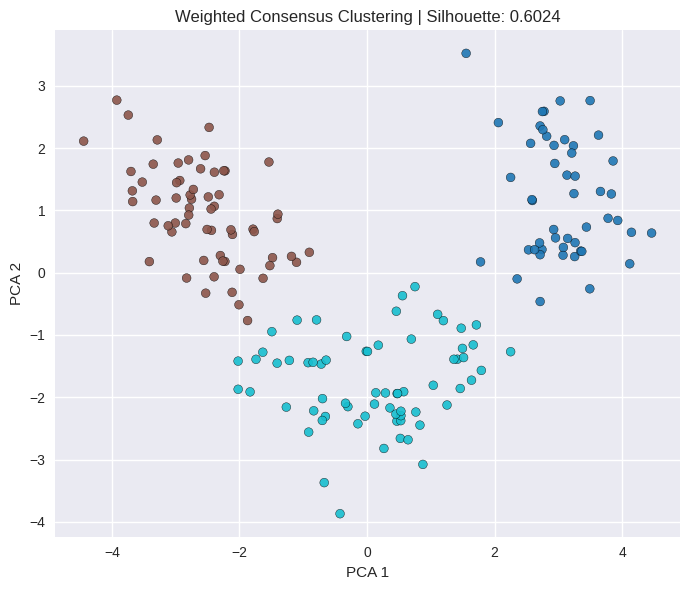

,Algorithm,Silhouette Score
0,KMeans,0.6024
1,FCM,0.6024
2,Consensus,0.6024
3,GMM,0.6006
4,Spectral,0.6005
5,DBSCAN,0.3158
6,OPTICS,-0.1649


In [ ]:
def run_weighted_consensus_clustering(
    X_red, cluster_label_list, method='weighted',
    n_clusters=None, visualize=True, sample_size=1000
):
    from sklearn.preprocessing import LabelEncoder
    import numpy as np
    import matplotlib.pyplot as plt

    cluster_outputs, cluster_scores, score_dict = [], [], {}

    print("Scoring individual base clusterings...")
    for labels, name in cluster_label_list:
        try:
            labels_enc = LabelEncoder().fit_transform(labels)
            score = safe_silhouette(X_red, labels_enc, sample_size=sample_size)
            cluster_outputs.append(labels_enc)
            cluster_scores.append(score)
            score_dict[name] = score
        except Exception as e:
            print(f"Skipping {name} due to error in scoring: {e}")
            continue
    print("Base cluster scores collected.")

    try:
        print("Building consensus matrix...")
        consensus_matrix = create_enhanced_consensus_matrix(cluster_outputs, cluster_scores, method)
    except Exception as e:
        print("Consensus matrix creation failed:", str(e))
        return None

    # Skipped consensus matrix plotting

    if n_clusters is None:
        n_clusters = int(np.mean([len(set(l)) for l in cluster_outputs]))
        print(f"Inferred number of clusters: {n_clusters}")

    try:
        print(f"Running Spectral Clustering with k={n_clusters}...")
        final_model = SpectralClustering(n_clusters=n_clusters, affinity='precomputed', random_state=42)
        final_labels = final_model.fit_predict(consensus_matrix)
    except Exception as e:
        print("Final clustering failed:", str(e))
        return None

    try:
        final_score = safe_silhouette(X_red, final_labels, sample_size=sample_size)
        print(f"Final consensus clustering silhouette score: {final_score:.4f}")
    except Exception as e:
        print("Could not calculate final silhouette score:", str(e))
        final_score = 0

    try:
        plt.figure(figsize=(7, 6))
        plt.scatter(X_red[:, 0], X_red[:, 1], c=final_labels, cmap='tab10', s=40, edgecolor='k', alpha=0.9)
        plt.title(f"Weighted Consensus Clustering | Silhouette: {final_score:.4f}")
        plt.xlabel("PCA 1")
        plt.ylabel("PCA 2")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print("Plotting failed:", str(e))

    return final_labels, consensus_matrix, score_dict

# Run and compare
result = run_weighted_consensus_clustering(
    X_red, cluster_label_list, method='weighted',
    n_clusters=k_best, visualize=True, sample_size=1000
)

if result is not None:
    final_labels, consensus_matrix, base_scores = result
    try:
        consensus_score = safe_silhouette(X_red, final_labels, sample_size=1000)
    except Exception as e:
        print("Failed to compute consensus silhouette score:", str(e))
        consensus_score = 0

    comparison_data = list(base_scores.items()) + [("Consensus", consensus_score)]
    comparison_df = pd.DataFrame(comparison_data, columns=["Algorithm", "Silhouette Score"])
    comparison_df.sort_values("Silhouette Score", ascending=False, inplace=True)
    comparison_df.reset_index(drop=True, inplace=True)

    def highlight_consensus(row):
        return ['background-color: gray; font-weight: bold;' if row['Algorithm'] == 'Consensus' else '' for _ in row]

    styled_table = comparison_df.style.apply(highlight_consensus, axis=1).format({"Silhouette Score": "{:.4f}"})
    display(styled_table)
else:
    print("Consensus clustering failed. No comparison table generated.")
